# Лаба 1.05

### Математические функции и XML

In [1]:
from meas import *

from math import *
from sympy import *
import numpy as np

from pprint import pprint
from lxml import etree

# Парсим XML
dom = etree.parse('latex.xml')
xml = dom.getroot()

print()

<Figure size 640x480 with 0 Axes>

### Результаты измерений

In [2]:
delta_t = 0.01
delta_phi = 1

N_exp1 = 10
direct_t = DirectMultipleMeasurement([18.21, 18.24, 18.24], delta_t)

Z_exp2 = 0
phi_start_exp2 = 30
phi_exp2 = [25, 20, 15, 10, 5, 0]
direct_exp2 = [
    [40.40, 83.97, 137.03, 206.86, 298.28, 491.66],
    [40.58, 88.05, 141.00, 211.54, 299.46, 486.34],
    [42.20, 87.70, 140.71, 209.64, 301.02, 488.55]
]

phi_start_exp3 = 15
N_exp3 = 5
direct_exp3 = {
    0.5: DirectMultipleMeasurement([7.80, 7.82, 7.87], delta_t),
    1:   DirectMultipleMeasurement([7.96, 7.95, 8.04], delta_t),
    2:   DirectMultipleMeasurement([8.48, 8.48, 8.47], delta_t),
    3:   DirectMultipleMeasurement([9.04, 9.10, 9.07], delta_t),
    4:   DirectMultipleMeasurement([9.59, 9.53, 9.63], delta_t),
    5:   DirectMultipleMeasurement([10.34, 10.40, 10.38], delta_t),
    5.5: DirectMultipleMeasurement([10.83, 10.87, 10.87], delta_t),
    6:   DirectMultipleMeasurement([11.15, 11.16, 11.12], delta_t),
    6.5: DirectMultipleMeasurement([11.82, 11.86, 11.85], delta_t)
}

m_cargo = Measurement(401 * 0.001, 2 * 0.001)
b_cargo = Measurement(40.0 * 0.001, 0.1 * 0.001)
l_0 = Measurement(25.2 * 0.001, 0.2 * 0.001)
l_1 = Measurement(57.0 * 0.001, 0.2 * 0.001)
m_kernel = Measurement(95.0 * 0.001, 0.2 * 0.001)
L_kernel = Measurement(22.0 * 0.01, 0.2 * 0.01)
r_kernel = Measurement(25.0 * 0.001, 0.2 * 0.001)
m_hub = Measurement(393 * 0.001, 0.5 * 0.001)
r_hub = Measurement(24.0 * 0.001, 0.2 * 0.001)

### Рассчёты

In [3]:
print('Среднее время 10 колебаний t =' , direct_t)
T = Measurement(direct_t._value_ / 10, direct_t._delta_ / 10)
print('Период колебания маятника T =', T)

Среднее время 10 колебаний t = 18.23±0.04 ε = 0.24 (18.23 Δ = 0.043513727 ε = 0.238692963)
Период колебания маятника T = 1.823±0.004 ε = 0.24 (1.823 Δ = 0.004351373 ε = 0.238692963)


In [4]:
t_average_exp2 = []
for i in range(len(direct_exp2[0])):
    values = [x[i] for x in direct_exp2]
    t_average_exp2.append(DirectMultipleMeasurement(values, delta_t).asMeasurment)
A_lin = [Measurement(x, delta_phi) for x in phi_exp2]
A_log = [Measurement(ln(x/phi_start_exp2), (2/3)*sqrt((delta_phi/x)**2 + (delta_phi/phi_start_exp2)**2)) if x!=0 else Measurement(-3, 0) for x in phi_exp2[:-1]]
print('Амплитуда     =', A_lin)
print('Логарифмичная =', A_log)
print('Время         =', t_average_exp2)

Амплитуда     = [25.0±1.0 ε = 4.0, 20.0±1.0 ε = 5.0, 15.0±1.0 ε = 7.0, 10.0±1.0 ε = 10.0, 5.0±1.0 ε = 20.0, 0.0±1.0 ε = 0]
Логарифмичная = [-0.182±0.035 ε = 19.0, -0.41±0.04 ε = 10.0, -0.69±0.05 ε = 7.0, -1.10±0.07 ε = 6.0, -1.79±0.14 ε = 8.0]
Время         = [41.1±2.5 ε = 6.0, 87±6 ε = 6.0, 140±5 ε = 3.9, 209±6 ε = 2.8, 299.6±3.4 ε = 1.1, 489±7 ε = 1.4]


Время выполнения = 0:00:00.023984


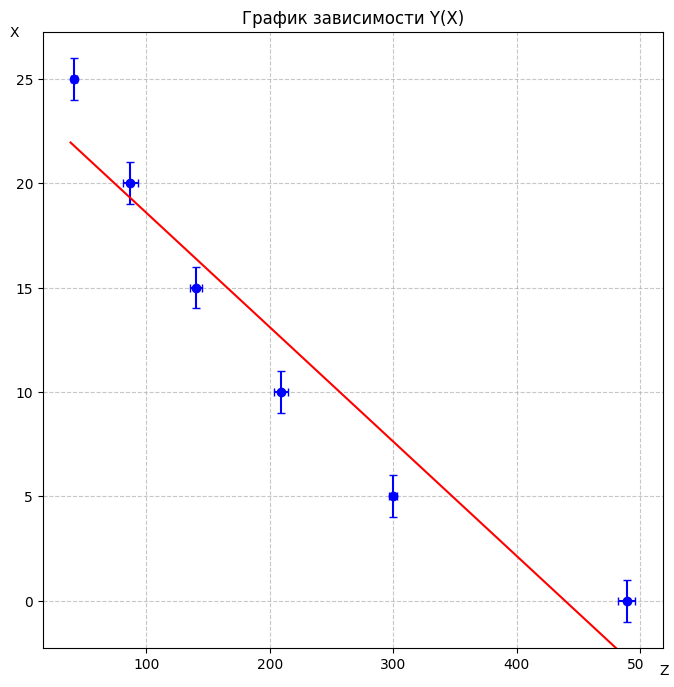

In [5]:
A_lin_DMM = DrawableMultipleMeasurement(t_average_exp2, A_lin)
A_lin_DMM.plot_MKN()

Время выполнения = 0:00:00.011485


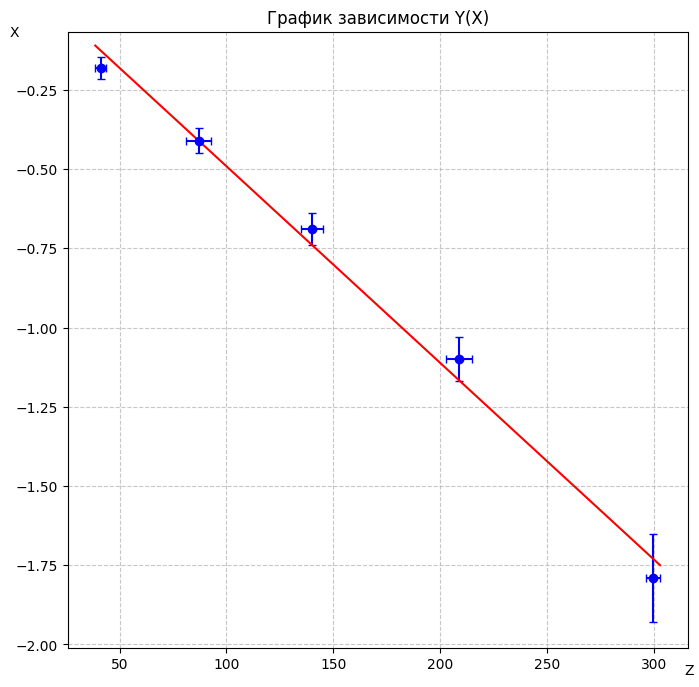

In [6]:
A_log_DMM = DrawableMultipleMeasurement(t_average_exp2[:-1], A_log)
A_log_DMM.plot_MKN()

Преобладает вязкое трение, т.к. график $ln\frac{A}{A_0}(t)$ больше похож на линейный.

In [7]:
print(A_lin_DMM.info)
print(A_log_DMM.info)

y = a + bx: y = 24-0.055x
a = 24±4 ε = 17.0 (24.059246566132 Δ = 4.106731173 ε = 17.069242636)
b = -0.055±0.016 ε = 29.0 (-0.054796143949 Δ = 0.015877137 ε = 28.974916872)
y = a + bx: y = 0.130000000000-0.006200000000x
a = 0.13±0.12 ε = 90.0 (0.129032884511 Δ = 0.120480626 ε = 93.372032185)
b = -0.0062±0.0007 ε = 11.0 (-0.006201197407 Δ = 0.000668719 ε = 10.783711125)


Для сухого (не моё):